# Lower-limb paper figures

Two compact figures combine the ideal and real trajectories with their paired `ideal - real` differences. Outlier participant-speed trials are removed for both treadmill models before aggregation.

In [87]:
# Configuration
RESULT_SUBFOLDER = "ideal_0814_e300_grf5e3_middleStiff_real_0814_e300_grf5e3_middleStiff"  # "grf3_angles1"
SPEEDS = [1.0, 1.2, 1.4, 1.6, 1.8]
EXCLUDE_OBJECTIVE_OUTLIERS = True
EXCLUDE_PARTICIPANT_SPEEDS = [("P5", 1.2), ("P7", 1.4), ("P8", 1.6)]
EXPORT_FIGURES = False

In [88]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "result_HC").is_dir() else cwd.parent
if not (ROOT / "result_HC").is_dir():
    raise FileNotFoundError("Could not find the repository's result directory.")

safe_name = re.sub(r"[^A-Za-z0-9]+", "_", RESULT_SUBFOLDER).strip("_")
trajectory_path = ROOT / "result_HC" / f"simulation_results_101_points_{safe_name}.csv"
outlier_path = ROOT / "result_HC" / f"objective_outliers_{safe_name}.csv"

outlier_trials = pd.DataFrame(columns=["participant", "speed"])
if EXCLUDE_OBJECTIVE_OUTLIERS:
    outlier_rows = pd.read_csv(outlier_path)
    exclusion_column = (
        "exclude_pair" if "exclude_pair" in outlier_rows.columns
        else "objective_outlier"
    )
    if exclusion_column in outlier_rows.columns:
        is_outlier = (
            outlier_rows[exclusion_column].eq(True)
            | outlier_rows[exclusion_column].astype(str).str.lower().eq("true")
        )
        outlier_rows = outlier_rows.loc[is_outlier]
    outlier_trials = outlier_rows[["participant", "speed"]].drop_duplicates()

manual_exclusions = pd.DataFrame(
    EXCLUDE_PARTICIPANT_SPEEDS, columns=["participant", "speed"]
)
outlier_trials = (
    pd.concat([outlier_trials, manual_exclusions], ignore_index=True)
    .drop_duplicates()
)

print(f"Participant-speed trials excluded from both models: {len(outlier_trials)}")
outlier_trials.sort_values(["participant", "speed"])

Participant-speed trials excluded from both models: 7


,participant,speed
0,P10,1.0
1,P10,1.4
2,P10,1.6
3,P10,1.8
4,P5,1.2
5,P7,1.4
6,P8,1.6


In [89]:
# Same dataframe logic as 2_a_lower_limb_kinematics_kinetics.ipynb.
df = pd.read_csv(trajectory_path)
# BioSym stores knee extension as positive. Flip the knee angle and moment
# for a consistent paper presentation in which flexion is positive.
df["q_knee_r_deg"] = -df["q_knee_r_deg"]
df["M_knee_r_nm_per_kg"] = -df["M_knee_r_nm_per_kg"]
excluded_index = pd.MultiIndex.from_frame(outlier_trials)
trial_index = pd.MultiIndex.from_frame(df[["participant", "speed"]])
df = df.loc[~trial_index.isin(excluded_index)].copy()

# Use the same complete participant-speed cohort for both model overlays and
# paired differences: every retained case must contain ideal and real results.
models_by_trial = (
    df[["participant", "speed", "treadmill_model"]]
    .drop_duplicates()
    .groupby(["participant", "speed"])["treadmill_model"]
    .agg(frozenset)
)
complete_pair_index = pd.MultiIndex.from_tuples(
    [trial for trial, models_present in models_by_trial.items()
     if {"ideal", "real"}.issubset(models_present)],
    names=["participant", "speed"],
)
incomplete_trials = models_by_trial.loc[
    ~models_by_trial.index.isin(complete_pair_index)
]
trial_index = pd.MultiIndex.from_frame(df[["participant", "speed"]])
df = df.loc[trial_index.isin(complete_pair_index)].copy()
print(
    f"Excluded {len(incomplete_trials)} additional participant-speed trials "
    "without both ideal and real results."
)
df = df.set_index(["participant", "speed", "treadmill_model", "node"]).sort_index()

mean_trajectories = df.groupby(
    level=["treadmill_model", "speed", "node"]
).mean(numeric_only=True)
std_trajectories = df.groupby(
    level=["treadmill_model", "speed", "node"]
).std(numeric_only=True)

angle_columns = ["q_hip_r_deg", "q_knee_r_deg", "q_ankle_r_deg"]
moment_columns = ["M_hip_r_nm_per_kg", "M_knee_r_nm_per_kg", "M_ankle_r_nm_per_kg"]
activation_columns = ["activation_gastroc_r", "activation_tibialis_ant_r"]
metric_columns = angle_columns + moment_columns + activation_columns

# Pair ideal and real within participant, speed, and node before averaging differences.
paired = df[metric_columns].unstack("treadmill_model")
differences = (
    paired.xs("ideal", level="treadmill_model", axis=1)
    - paired.xs("real", level="treadmill_model", axis=1)
)
mean_differences = differences.groupby(level=["speed", "node"]).mean()
std_differences = differences.groupby(level=["speed", "node"]).std()

Excluded 0 additional participant-speed trials without both ideal and real results.


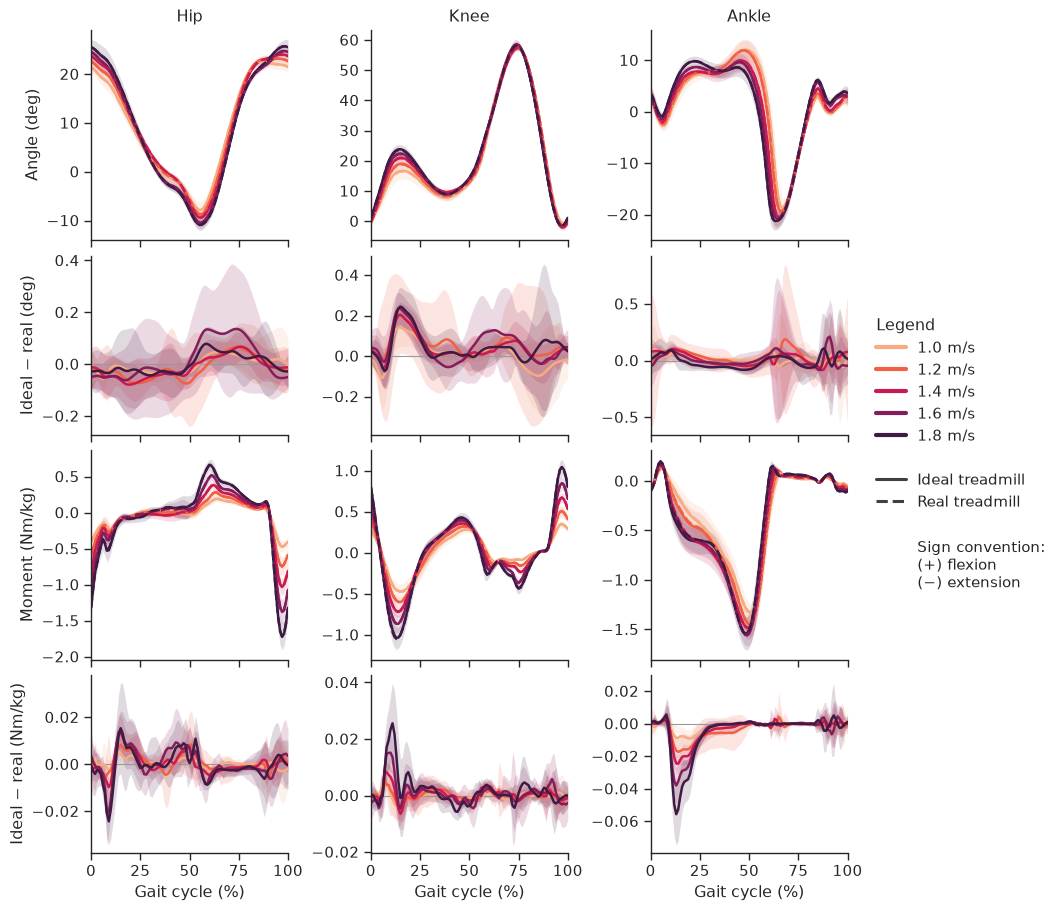

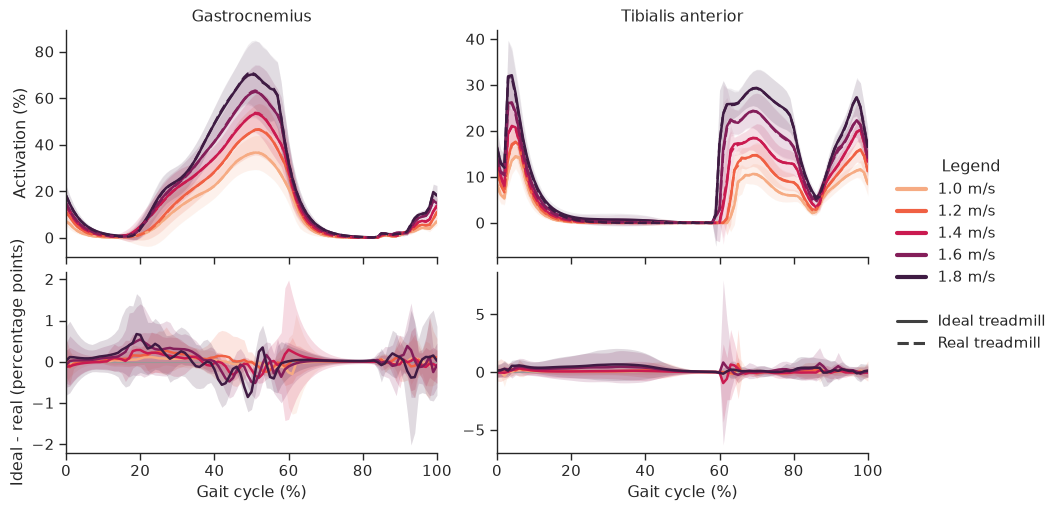

In [94]:
models = ["ideal", "real"]
model_styles = {"ideal": "-", "real": "--"}
speed_colors = dict(zip(SPEEDS, sns.color_palette("rocket_r", n_colors=len(SPEEDS))))
speed_handles = [
    Line2D([0], [0], color=speed_colors[speed], lw=3, label=f"{speed:.1f} m/s")
    for speed in SPEEDS
]
model_handles = [
    Line2D([0], [0], color="0.25", lw=2.2, linestyle="-", label="Ideal treadmill"),
    Line2D([0], [0], color="0.25", lw=2.2, linestyle="--", label="Real treadmill"),
]
legend_gap = Line2D([], [], linestyle="none", label=" " )
sign_convention_handle = Line2D(
    [], [], linestyle="none", label="Sign convention:\n(+) flexion\n(−) extension"
)
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

def plot_trajectory(ax, column, scale=1):
    for model in models:
        for speed in SPEEDS:
            mean = mean_trajectories.loc[(model, speed), column] * scale
            std = std_trajectories.loc[(model, speed), column] * scale
            ax.plot(
                mean.index, mean.to_numpy(), color=speed_colors[speed],
                linestyle=model_styles[model], linewidth=1.8,
            )
            ax.fill_between(
                mean.index, (mean - std).to_numpy(), (mean + std).to_numpy(),
                color=speed_colors[speed], alpha=0.08, linewidth=0,
            )

def plot_difference(ax, column, scale=1):
    ax.axhline(0, color="0.6", linewidth=0.8)
    for speed in SPEEDS:
        mean = mean_differences.loc[speed, column] * scale
        std = std_differences.loc[speed, column] * scale
        ax.plot(mean.index, mean.to_numpy(), color=speed_colors[speed], linewidth=1.8)
        ax.fill_between(
            mean.index, (mean - std).to_numpy(), (mean + std).to_numpy(),
            color=speed_colors[speed], alpha=0.16, linewidth=0,
        )

# Figure 1: angles and moments, each followed by paired differences.
joint_names = ["Hip", "Knee", "Ankle"]
fig_joint, axes = plt.subplots(
    4, 3, figsize=(10.5, 9), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 0.85, 1, 0.85]},
)
for col, (joint, angle_column, moment_column) in enumerate(zip(joint_names, angle_columns, moment_columns)):
    plot_trajectory(axes[0, col], angle_column)
    plot_difference(axes[1, col], angle_column)
    plot_trajectory(axes[2, col], moment_column)
    plot_difference(axes[3, col], moment_column)
    axes[0, col].set_title(joint)
    axes[3, col].set_xlabel("Gait cycle (%)")
    for row in range(4):
        axes[row, col].set_xlim(0, 100)

axes[0, 0].set_ylabel("Angle (deg)")
axes[1, 0].set_ylabel("Ideal − real (deg)")
axes[2, 0].set_ylabel("Moment (Nm/kg)")
axes[3, 0].set_ylabel("Ideal − real (Nm/kg)")

joint_legend = fig_joint.legend(
    handles=speed_handles + [legend_gap] + model_handles
    + [legend_gap, sign_convention_handle],
    title="Legend", loc="outside right center",
    frameon=False, alignment="left",
)
# Align the handle-free sign note with the colored line samples rather than
# with the other entry labels, while keeping everything in one legend.
sign_text = joint_legend.get_texts()[-1]
sign_text.set_x(-28)
sns.despine(fig=fig_joint)

# Figure 2: muscle activations and their paired differences.
muscle_names = ["Gastrocnemius", "Tibialis anterior"]
# Match the joint figure's native width so equal LaTeX include widths
# produce the same apparent font and line sizes.
fig_activation, activation_axes = plt.subplots(
    2, 2, figsize=(10.5, 5.0), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 0.8]},
)
for col, (muscle, column) in enumerate(zip(muscle_names, activation_columns)):
    plot_trajectory(activation_axes[0, col], column, scale=100)
    plot_difference(activation_axes[1, col], column, scale=100)
    activation_axes[0, col].set_title(muscle)
    activation_axes[1, col].set_xlabel("Gait cycle (%)")
    activation_axes[0, col].set_xlim(0, 100)
    activation_axes[1, col].set_xlim(0, 100)

activation_axes[0, 0].set_ylabel("Activation (%)")
activation_axes[1, 0].set_ylabel("Ideal - real (percentage points)")
fig_activation.legend(
    handles=speed_handles + [legend_gap] + model_handles, title="Legend",
    loc="outside right center", frameon=False,
)
sns.despine(fig=fig_activation)

if EXPORT_FIGURES:
    joint_output = ROOT / "result_HC" / f"paper_joint_trajectories_differences_{safe_name}.pdf"
    activation_output = ROOT / "result_HC" / f"paper_activations_differences_{safe_name}.pdf"
    fig_joint.savefig(joint_output, bbox_inches="tight")
    fig_activation.savefig(activation_output, bbox_inches="tight")
    print(f"Saved {joint_output.relative_to(ROOT)}")
    print(f"Saved {activation_output.relative_to(ROOT)}")


In [91]:
mean_per_speed = (
    differences[angle_columns]
    .groupby(level=["speed", "node"])
    .mean()
)

display(mean_per_speed)

q_hip_r_deg  q_knee_r_deg  q_ankle_r_deg
speed node                                          
1.0   0       -0.003586     -0.019913       0.034113
      1       -0.012112     -0.021736       0.093636
      2       -0.020839     -0.033732       0.106144
      3       -0.031595     -0.054892       0.097639
      4       -0.043116     -0.080464       0.081988
...                 ...           ...            ...
1.8   96      -0.021756      0.062614       0.080553
      97      -0.025025      0.053181       0.069133
      98      -0.027055      0.042242       0.045683
      99      -0.028105      0.032071       0.025282
      100     -0.028136      0.023601       0.016200

[505 rows x 3 columns]

In [92]:
joint_differences_long = (
    differences[angle_columns]
    .rename_axis(columns="joint")
    .stack()
    .rename("difference")
    .reset_index()
)

joint_differences_long["absolute_difference"] = (
    joint_differences_long["difference"].abs()
)

maximum_indices = (
    joint_differences_long
    .groupby(["participant", "joint"])["absolute_difference"]
    .idxmax())

participant_maxima = (
    joint_differences_long
    .loc[maximum_indices]
    .sort_values(["participant", "joint"])
    .reset_index(drop=True)
)

display(participant_maxima[participant_maxima.joint=="q_ankle_r_deg"])

,participant,speed,node,joint,difference,absolute_difference
0,P1,1.6,91,q_ankle_r_deg,-0.377815,0.377815
3,P10,1.2,95,q_ankle_r_deg,0.602945,0.602945
6,P11,1.2,95,q_ankle_r_deg,-0.518518,0.518518
9,P12,1.4,65,q_ankle_r_deg,1.362280,1.362280
12,P13,1.2,68,q_ankle_r_deg,2.470754,2.470754
15,P14,1.6,92,q_ankle_r_deg,0.812123,0.812123
18,P15,1.8,88,q_ankle_r_deg,0.415759,0.415759
21,P2,1.0,67,q_ankle_r_deg,0.712889,0.712889
24,P3,1.6,64,q_ankle_r_deg,2.003001,2.003001
27,P4,1.2,0,q_ankle_r_deg,0.925227,0.925227


In [38]:
mean_per_speed.groupby(level=["speed"]).min()

,q_hip_r_deg,q_knee_r_deg,q_ankle_r_deg
speed,,,
1.0,-0.056871,-0.141179,-0.065780
1.2,-0.074581,-0.204478,-0.075081
1.4,-0.079040,-0.204152,-0.085205
1.6,-0.062330,-0.235166,-0.083665
1.8,-0.043284,-0.244497,-0.081736


In [39]:
mean_per_speed.groupby(level=["speed"]).max()

,q_hip_r_deg,q_knee_r_deg,q_ankle_r_deg
speed,,,
1.0,0.047263,0.107827,0.106144
1.2,0.066237,0.013844,0.188697
1.4,0.067460,0.057042,0.101817
1.6,0.135807,0.054479,0.210755
1.8,0.078250,0.074986,0.107943


## Maximum ideal − real differences

The first table averages the paired trajectories over participants and then finds the largest absolute difference for every speed and metric. The second table finds the largest absolute difference for every participant and metric across all speeds and gait-cycle nodes. In both tables, `difference` retains the signed ideal − real value, while `absolute_difference` is used only to select the maximum. Activation differences are reported in percentage points.

In [40]:
# Maximum of the participant-averaged difference trajectory, per speed and metric.
mean_difference_long = (
    mean_differences[metric_columns]
    .rename_axis(columns="metric")
    .stack()
    .rename("difference")
    .reset_index()
)
mean_activation_rows = mean_difference_long["metric"].isin(activation_columns)
mean_difference_long.loc[mean_activation_rows, "difference"] *= 100
mean_difference_long["absolute_difference"] = (
    mean_difference_long["difference"].abs()
)
mean_maximum_indices = (
    mean_difference_long
    .groupby(["speed", "metric"])["absolute_difference"]
    .idxmax()
)
mean_difference_extrema = (
    mean_difference_long
    .loc[mean_maximum_indices, [
        "speed", "metric", "node", "difference", "absolute_difference"
    ]]
    .sort_values(["metric", "speed"])
    .reset_index(drop=True)
)
display(mean_difference_extrema)

,speed,metric,node,difference,absolute_difference
0,1.0,M_ankle_r_nm_per_kg,20,-0.009165,0.009165
1,1.2,M_ankle_r_nm_per_kg,14,-0.017297,0.017297
2,1.4,M_ankle_r_nm_per_kg,14,-0.024560,0.024560
3,1.6,M_ankle_r_nm_per_kg,13,-0.037972,0.037972
4,1.8,M_ankle_r_nm_per_kg,13,-0.055662,0.055662
5,1.0,M_hip_r_nm_per_kg,14,0.005375,0.005375
6,1.2,M_hip_r_nm_per_kg,51,0.008326,0.008326
7,1.4,M_hip_r_nm_per_kg,15,0.013435,0.013435
8,1.6,M_hip_r_nm_per_kg,9,-0.020471,0.020471
9,1.8,M_hip_r_nm_per_kg,9,-0.024300,0.024300


In [44]:
# Maximum difference for every participant and metric across speeds and nodes.
participant_difference_long = (
    differences[metric_columns]
    .rename_axis(columns="metric")
    .stack()
    .rename("difference")
    .reset_index()
)
participant_activation_rows = (
    participant_difference_long["metric"].isin(activation_columns)
)
participant_difference_long.loc[
    participant_activation_rows, "difference"
] *= 100
participant_difference_long["absolute_difference"] = (
    participant_difference_long["difference"].abs()
)
participant_maximum_indices = (
    participant_difference_long
    .groupby(["participant", "metric"])["absolute_difference"]
    .idxmax()
)
participant_difference_extrema = (
    participant_difference_long
    .loc[participant_maximum_indices, [
        "participant", "metric", "speed", "node",
        "difference", "absolute_difference"
    ]]
    .sort_values(["participant", "metric"])
    .reset_index(drop=True)
)


In [45]:
for metric in metric_columns:
    metric_extrema = (
        participant_difference_extrema
        .loc[
            participant_difference_extrema["metric"] == metric,
            [
                "participant",
                "speed",
                "node",
                "difference",
                "absolute_difference",
            ],
        ]
        .reset_index(drop=True)
    )

    print(f"\n{metric}")
    display(metric_extrema)


q_hip_r_deg


,participant,speed,node,difference,absolute_difference
0,P1,1.2,42,-0.426390,0.426390
1,P10,1.2,85,-0.152576,0.152576
2,P11,1.8,41,-0.124568,0.124568
3,P12,1.4,3,0.238993,0.238993
4,P13,1.2,51,-0.634548,0.634548
5,P14,1.2,41,0.424302,0.424302
6,P15,1.6,72,0.311469,0.311469
7,P2,1.8,89,-0.230401,0.230401
8,P3,1.6,71,0.581390,0.581390
9,P4,1.2,8,-0.265541,0.265541



q_knee_r_deg


,participant,speed,node,difference,absolute_difference
0,P1,1.2,14,-0.265367,0.265367
1,P10,1.2,82,0.632657,0.632657
2,P11,1.6,87,0.335028,0.335028
3,P12,1.4,73,-0.381951,0.381951
4,P13,1.2,76,-1.056319,1.056319
5,P14,1.6,12,-0.436637,0.436637
6,P15,1.8,88,-0.324277,0.324277
7,P2,1.8,89,0.459117,0.459117
8,P3,1.6,68,-0.678965,0.678965
9,P4,1.2,9,0.683943,0.683943



q_ankle_r_deg


...

,participant,speed,node,difference,absolute_difference
0,P1,1.8,13,-0.056427,0.056427
1,P10,1.2,15,-0.017325,0.017325
2,P11,1.8,13,-0.037516,0.037516
3,P12,1.4,18,-0.037385,0.037385
4,P13,1.2,65,0.059285,0.059285
5,P14,1.8,13,-0.059299,0.059299
6,P15,1.8,13,-0.047161,0.047161
7,P2,1.8,14,-0.058593,0.058593
8,P3,1.8,13,-0.051869,0.051869
9,P4,1.8,14,-0.081420,0.081420



activation_gastroc_r


,participant,speed,node,difference,absolute_difference
0,P1,1.6,98,0.009518,0.009518
1,P10,1.2,93,-0.019542,0.019542
2,P11,1.6,93,0.014654,0.014654
3,P12,1.4,60,0.058989,0.058989
4,P13,1.2,98,0.033558,0.033558
5,P14,1.6,93,0.028548,0.028548
6,P15,1.6,22,0.017684,0.017684
7,P2,1.0,62,0.035165,0.035165
8,P3,1.6,17,0.023239,0.023239
9,P4,1.8,20,0.031491,0.031491



activation_tibialis_ant_r


,participant,speed,node,difference,absolute_difference
0,P1,1.8,91,0.010021,0.010021
1,P10,1.2,81,0.007856,0.007856
2,P11,1.8,4,0.014339,0.014339
3,P12,1.4,63,0.104298,0.104298
4,P13,1.2,65,0.111553,0.111553
5,P14,1.6,88,0.018198,0.018198
6,P15,1.6,32,0.020891,0.020891
7,P2,1.0,65,0.034883,0.034883
8,P3,1.6,61,0.234211,0.234211
9,P4,1.8,32,0.037944,0.037944
